# Supercooled Profiles from MEOP Platform 9900109

In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import scipy as sp
import mat73 # for loading .mat files version >= 7.3
from datetime import datetime, timedelta

# packages for plotting
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import cmocean.cm as cmo # ocean colormaps

# my own plotting functions
from obs_plotting_functions import *

## Load Data

In [2]:
filepath = "/isibhv/projects-noreplica/p_so-clim/alhaum001/supercool_profiles_merged_20200911.mat"
matstructs= mat73.loadmat(filepath) # this loads the matlab file as a python dictionary
matstructs.keys() # the dictionary keys (the names of the mat structures in the .mat file)

dict_keys(['data0', 'data1', 'data1_other', 'data2'])

In this Notebook, I look at supercooled MEOP / argofloat profiles from Haumann et al. (2020). The data is loaded from the file supercool_profiles_merged_20200911.mat. This file contains the following structures:
- data0: ?
- data1: metadata of the supercooled profiles
- data1_other: metadata of all profiles (or the non-supercooled?)
- data2: the supercooled profiles

In [3]:
data1 = matstructs['data1']
data1_other = matstructs['data1_other']
data2 = matstructs['data2']

### Add Datetime Variable to Data1 and Data1_other

In [4]:
# add datetime variable
matlab_zero_time = datetime(1,1,1) # Matlab's day zero is 0000-01-01, but Python's datetime starts at 0001-01-01, so we need to account for that when converting

# DATA1
days = data1["dates"]-1-366 # convert from Matlab's datenum to number of days since 0001-01-01, accounting for the fact that Matlab's datenum starts at 1 and includes a leap year in year 0
datetimes = [
    matlab_zero_time + timedelta(days=day) if day == day else float('nan') # convert to datetime, respecting NaN values
    for day in days
]

data1["datetimes"] = pd.Series(np.array(datetimes))

# DATA1_OTHER
days_other = data1_other["dates"]-1-366
datetimes_other = [
    matlab_zero_time + timedelta(days=day) if day == day else float('nan')
    for day in days_other
]

data1_other["datetimes"] = pd.Series(np.array(datetimes_other))


### Filter for Seal 9900109

In [5]:
mask_9900109 = (data1["id"] == 9900109)
data1_9900109 = {key: data1[key][mask_9900109] for key in data1.keys()}
data2_9900109 = {key: data2[key][:,mask_9900109] for key in data2.keys()}

mask_other_9900109 = (data1_other["id"] == 9900109)
data1_other_9900109 = {key: data1_other[key][mask_other_9900109] for key in data1_other.keys()}

### Create Dataset of All Profiles from Seal 9900109 (both supercooled and not supercooled)

In [6]:
# make dataframe with all profiles of this seal, both supercooled and not supercooled

# create empty dataframe
data1_9900109_all_df = pd.DataFrame()

for key in data1_9900109.keys():
    if key in data1_other_9900109.keys(): # for variables that exist in both data1 and data1_other just concatenate
        data1_9900109_all_df[key] = np.concatenate([data1_9900109[key], data1_other_9900109[key]])
    else: # otherwise insert values from and then fill up with nan
        nan_filler = np.empty(411) * np.nan
        data1_9900109_all_df[key] = np.concatenate([data1_9900109[key], nan_filler])

# sort by dates
data1_9900109_all_df = data1_9900109_all_df.sort_values("dates")

# crop to june-november
mask_time = data1_9900109_all_df.datetimes > datetime(2008,6,1)
data1_9900109_all_df = data1_9900109_all_df.loc[mask_time, :]
data1_9900109_all_df 

,bath,bot,bot_ps,cycle,dates,dcycle,ddates,f,flag,heat_ps,...,max_ps,max_ps_dpth,mld,pycno,seaice_iceshelf,surf,surf_ps,thickn_ps,types,datetimes
444,NaN,NaN,NaN,283.0,733560.152778,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0,2008-06-01 03:39:59.999998
445,NaN,NaN,NaN,284.0,733560.569444,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0,2008-06-01 13:40:00.000004
446,NaN,NaN,NaN,285.0,733560.812500,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0,2008-06-01 19:30:00.000000
447,NaN,NaN,NaN,286.0,733561.055556,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0,2008-06-02 01:19:59.999996
448,NaN,NaN,NaN,287.0,733561.354167,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0,2008-06-02 08:29:59.999997
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
204,4065.00,561.939812,105.976221,717.0,733740.791667,NaN,NaN,-0.000124,0.0,-9.398842e+06,...,-0.064374,98.054667,55.471050,93.598658,5.0,5.944048,60.423089,45.553132,3.0,2008-11-28 18:59:59.999997
205,4393.25,494.741718,NaN,718.0,733741.222222,NaN,NaN,-0.000125,0.0,-3.145837e+06,...,-0.016071,47.547104,55.470544,65.869594,0.0,5.943994,NaN,NaN,3.0,2008-11-29 05:20:00.000002
206,4065.25,494.742827,51.508978,719.0,733741.298611,NaN,NaN,-0.000125,0.0,-5.302087e+06,...,-0.024705,18.822095,55.470669,65.869741,1.0,5.944007,5.944007,45.564971,3.0,2008-11-29 07:10:00.000001
207,4306.75,579.723695,NaN,720.0,733741.569444,NaN,NaN,-0.000124,0.0,-5.074807e+05,...,-0.006914,17.831655,35.661753,53.985508,0.0,5.944058,NaN,NaN,3.0,2008-11-29 13:40:00.000004


## Map View

### Max Pot SC

In [7]:
data1_other.keys()

dict_keys(['cycle', 'dates', 'id', 'id2', 'lat', 'lon', 'types', 'datetimes'])

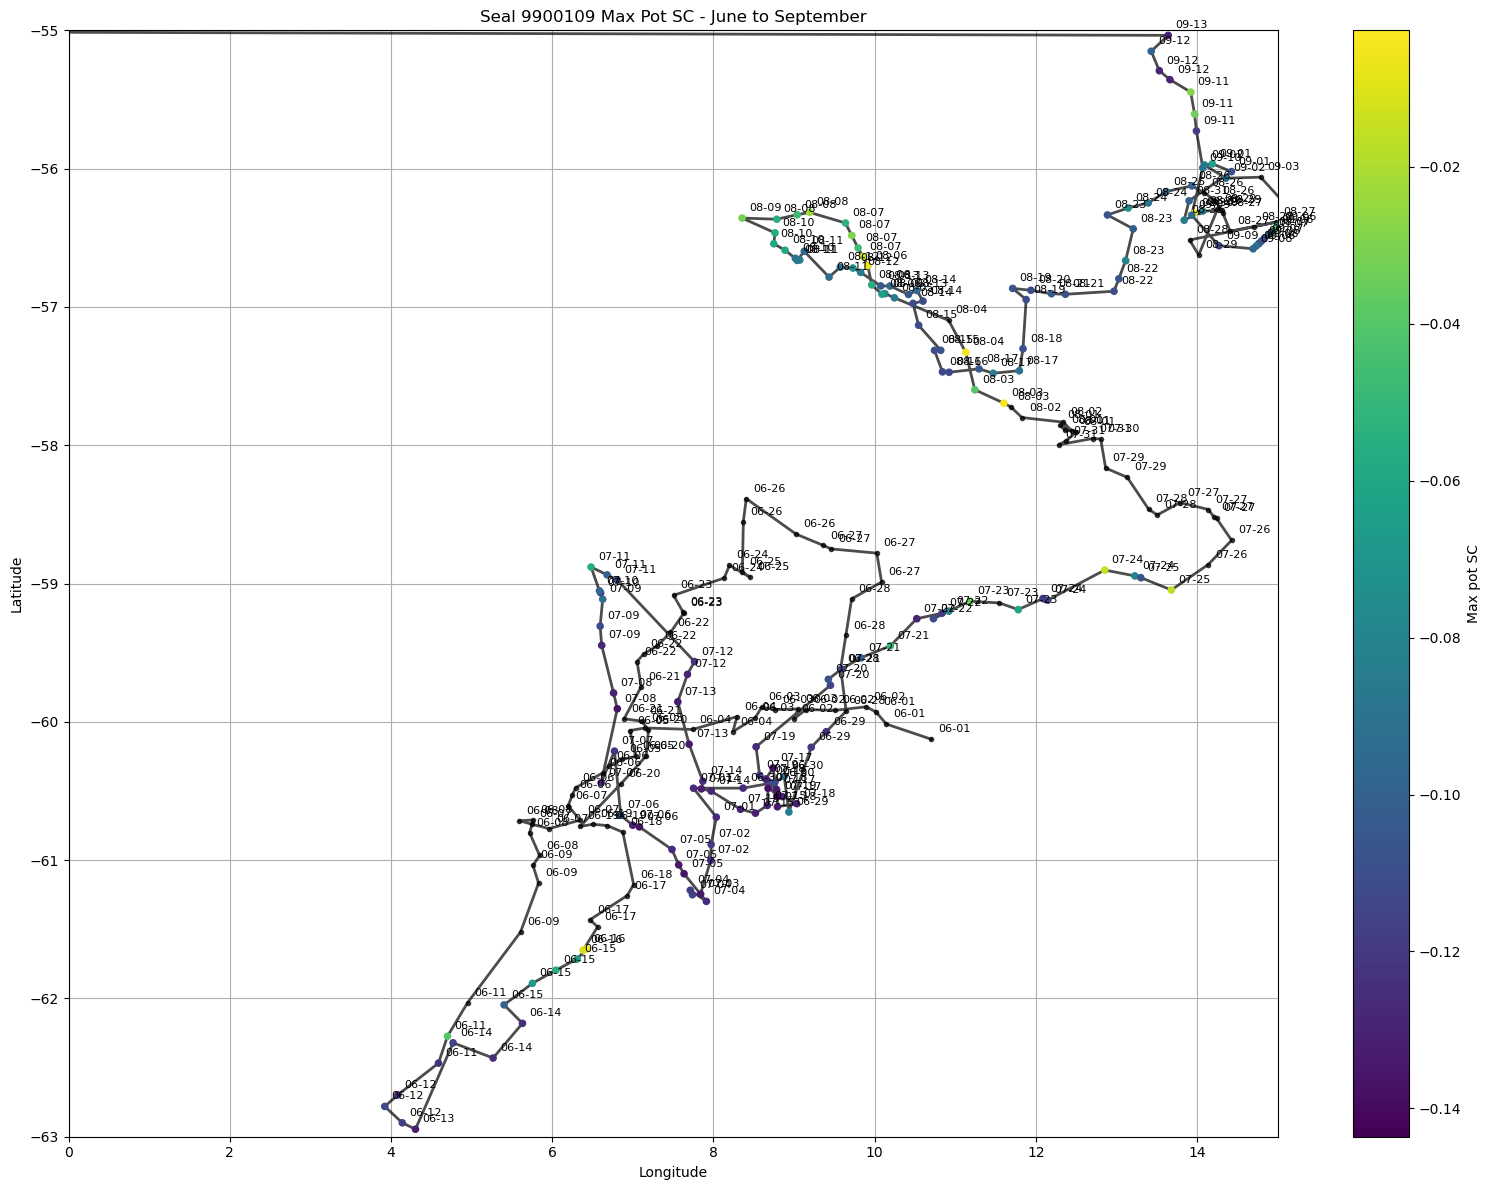

In [11]:
# MOVEMENT OF SEAL WITH MAX POT SC

# Plot
plt.figure(figsize=(16, 12))

# Draw the path line
plt.plot(data1_9900109_all_df['lon'], data1_9900109_all_df['lat'], '.-', linewidth=2, alpha=0.7, label='Movement Path', color = "black")


# Add scatter points with SC coloring
scatter = plt.scatter(data1_9900109_all_df['lon'], data1_9900109_all_df['lat'], c=data1_9900109_all_df["max_ps"], cmap='viridis', 
                      s=30, edgecolors='none', zorder=3, label='Locations')


# Apply the formatter to the colorbar
cbar = plt.colorbar(scatter)
cbar.set_label('Max pot SC')

# Annotate points with time
for i, row in data1_9900109_all_df.iterrows():
    plt.annotate(row['datetimes'].strftime('%m-%d'), (row['lon'], row['lat']), 
                 textcoords="offset points", xytext=(5,5), ha='left', fontsize=8, zorder=4)

# Label axes
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Seal 9900109 Max Pot SC - June to September')

plt.xlim(0,15)
plt.ylim(-63,-55)

plt.grid(True)
plt.tight_layout()
plt.show()

### Max SC Depth

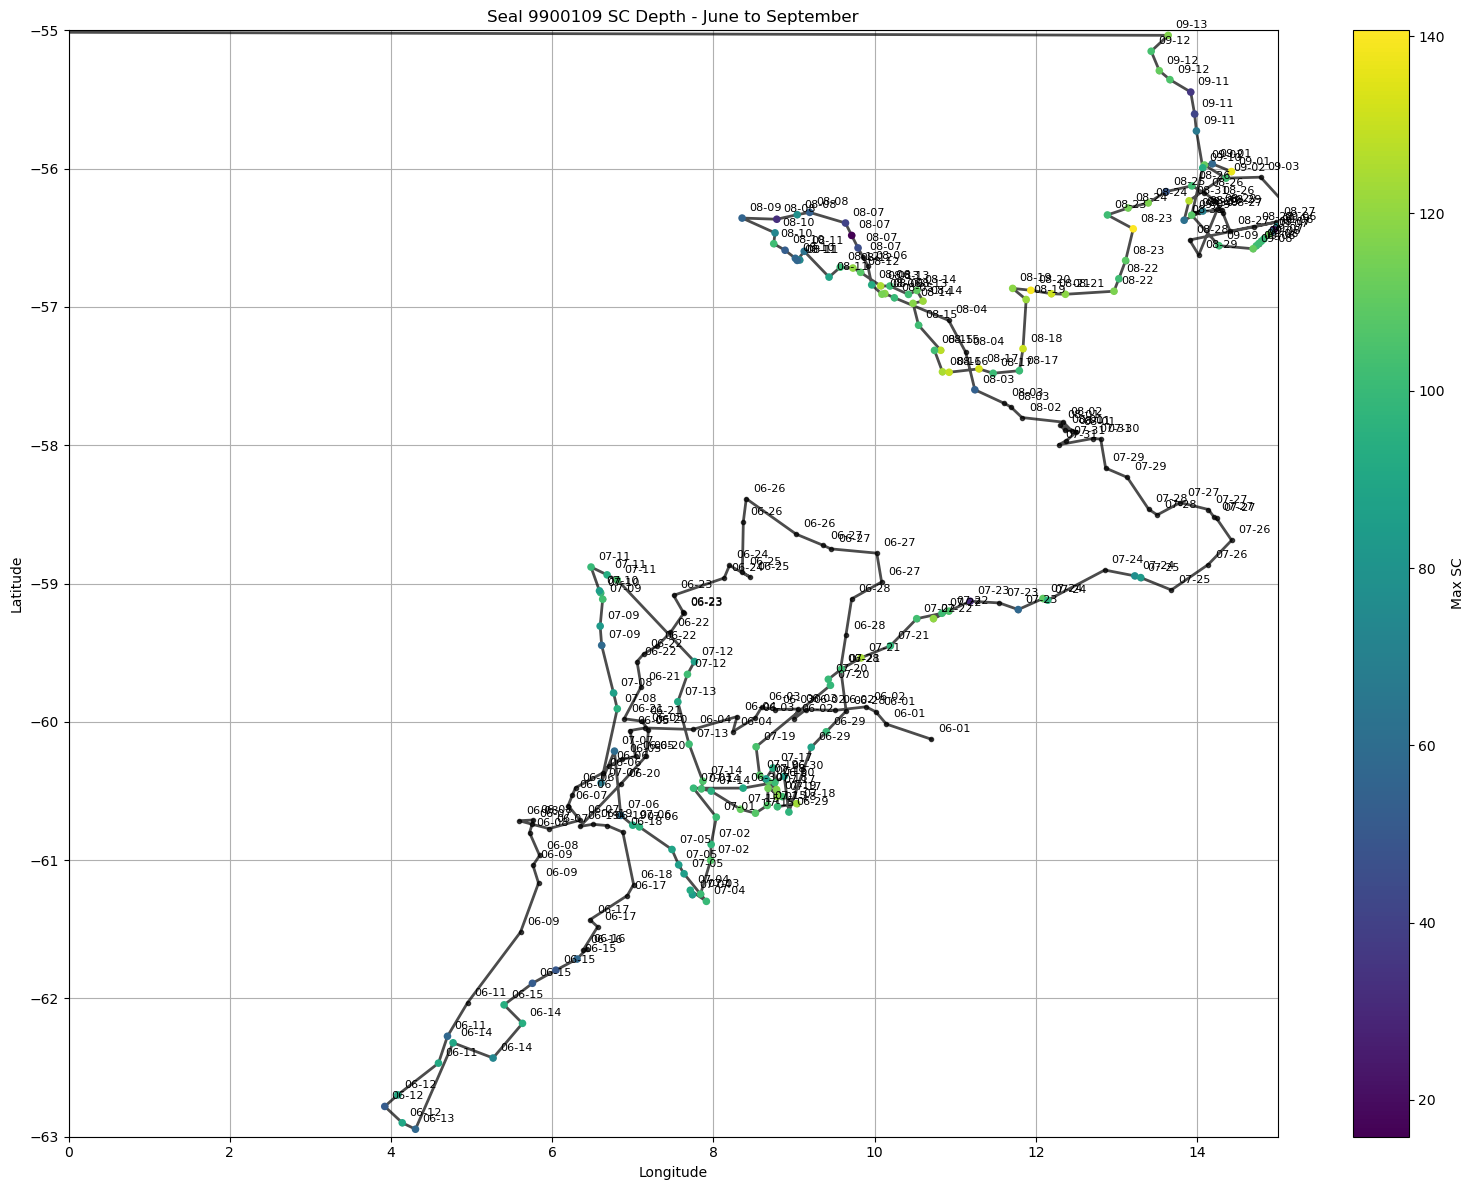

In [9]:
# MOVEMENT OF SEAL WITH MAX POT SC

# Plot
plt.figure(figsize=(16, 12))

# Draw the path line
plt.plot(data1_9900109_all_df['lon'], data1_9900109_all_df['lat'], '.-', linewidth=2, alpha=0.7, label='Movement Path', color = "black")


# Add scatter points with SC coloring
scatter = plt.scatter(data1_9900109_all_df['lon'], data1_9900109_all_df['lat'], c=data1_9900109_all_df["bot_ps"], cmap='viridis', 
                      s=30, edgecolors='none', zorder=3, label='Locations')


# Apply the formatter to the colorbar
cbar = plt.colorbar(scatter)
cbar.set_label('Max SC')

# Annotate points with time
for i, row in data1_9900109_all_df.iterrows():
    plt.annotate(row['datetimes'].strftime('%m-%d'), (row['lon'], row['lat']), 
                 textcoords="offset points", xytext=(5,5), ha='left', fontsize=8, zorder=4)

# Label axes
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Seal 9900109 SC Depth - June to September')

plt.xlim(0,15)
plt.ylim(-63,-55)

plt.grid(True)
plt.tight_layout()
plt.show()

### MLD Penetration

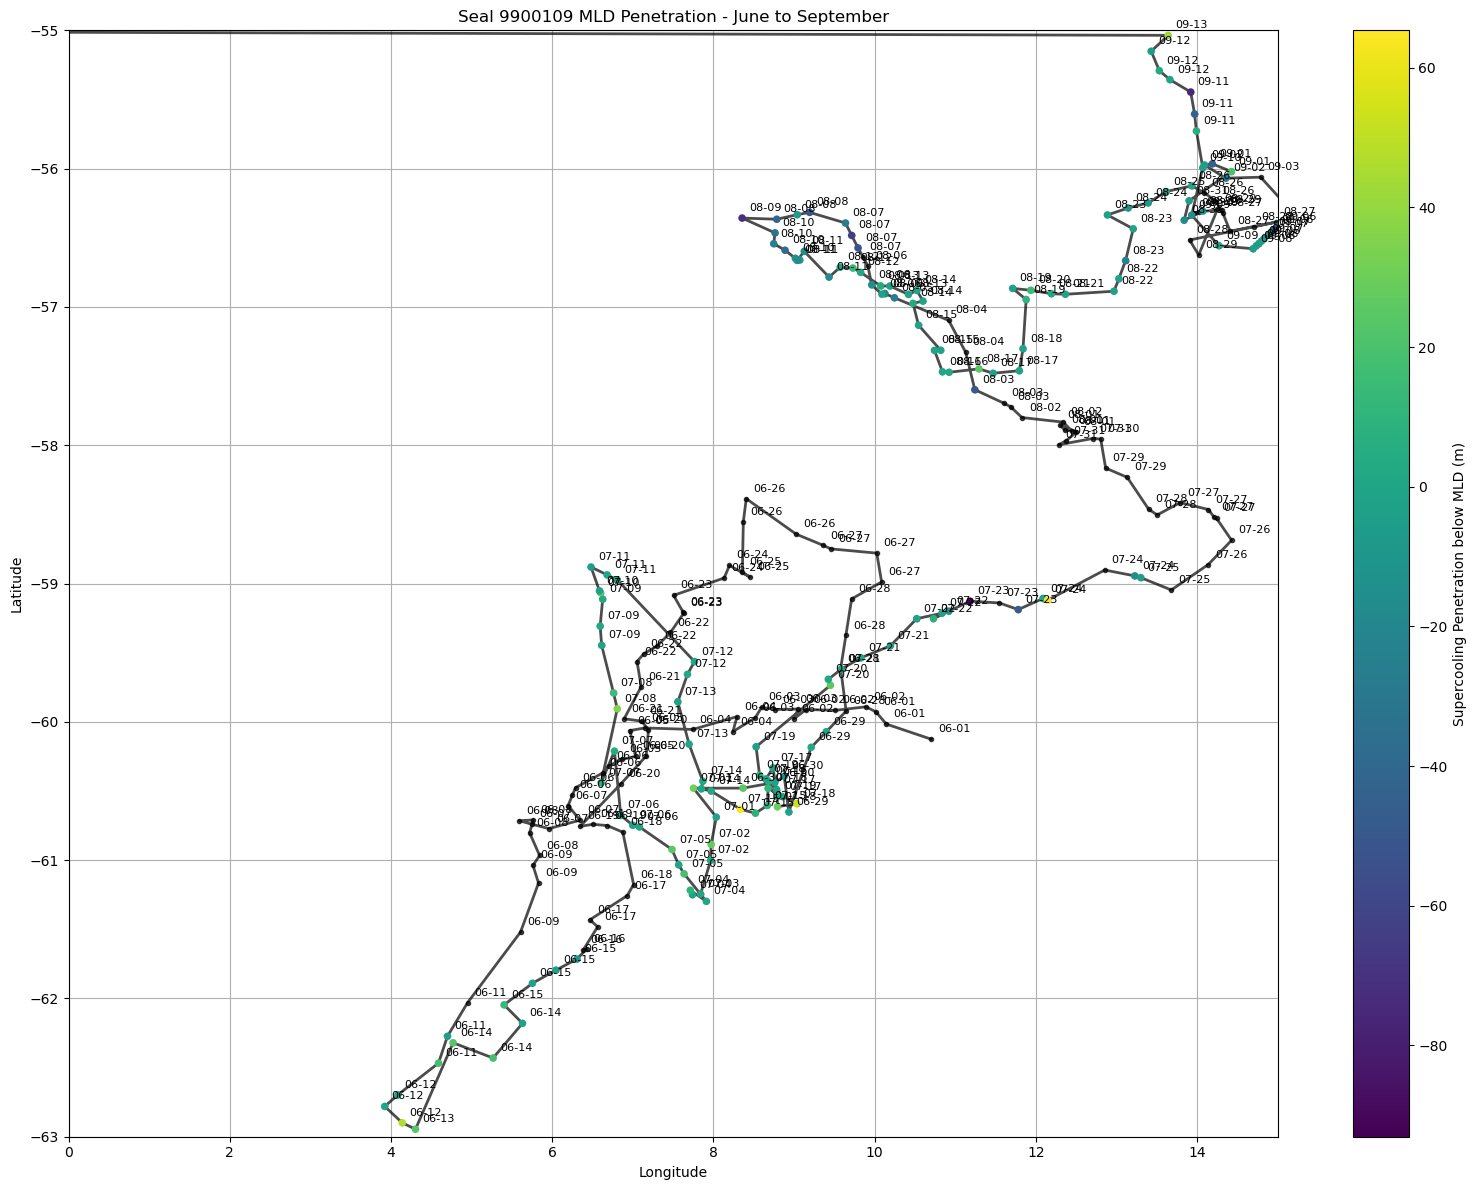

In [13]:
# MOVEMENT OF SEAL WITH MAX POT SC

# Plot
plt.figure(figsize=(16, 12))

# Draw the path line
plt.plot(data1_9900109_all_df['lon'], data1_9900109_all_df['lat'], '.-', linewidth=2, alpha=0.7, label='Movement Path', color = "black")


# Add scatter points with SC coloring
mld_penetration = data1_9900109_all_df["bot_ps"] - data1_9900109_all_df["mld"]
scatter = plt.scatter(data1_9900109_all_df['lon'], data1_9900109_all_df['lat'], c = mld_penetration, cmap='viridis', 
                      s=30, edgecolors='none', zorder=3, label='Locations')


# Apply the formatter to the colorbar
cbar = plt.colorbar(scatter)
cbar.set_label('Supercooling Penetration below MLD (m)')

# Annotate points with time
for i, row in data1_9900109_all_df.iterrows():
    plt.annotate(row['datetimes'].strftime('%m-%d'), (row['lon'], row['lat']), 
                 textcoords="offset points", xytext=(5,5), ha='left', fontsize=8, zorder=4)

# Label axes
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Seal 9900109 MLD Penetration - June to September')

plt.xlim(0,15)
plt.ylim(-63,-55)

plt.grid(True)
plt.tight_layout()
plt.show()

### July Zoom In

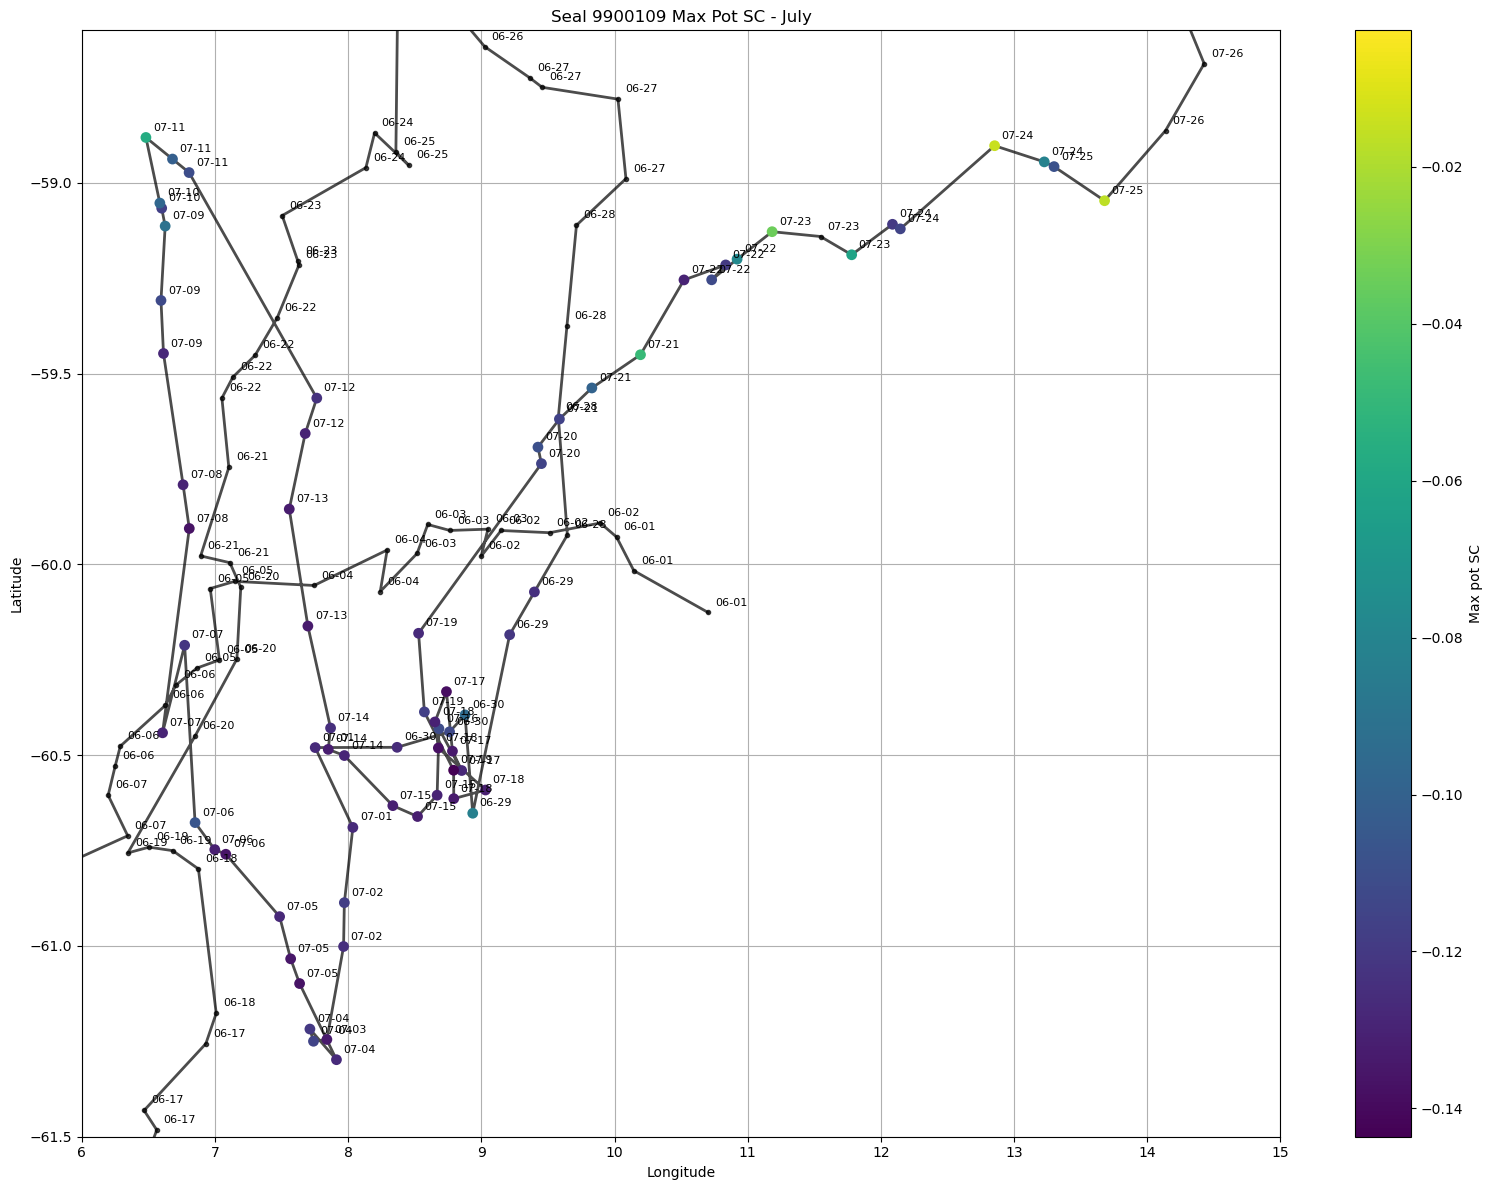

In [11]:
# MOVEMENT OF SEAL WITH MAX POT SC

# Plot
plt.figure(figsize=(16, 12))

# Draw the path line
plt.plot(data1_9900109_all_df['lon'], data1_9900109_all_df['lat'], '.-', linewidth=2, alpha=0.7, label='Movement Path', color = "black")


# Add scatter points with SC coloring
scatter = plt.scatter(data1_9900109_all_df['lon'], data1_9900109_all_df['lat'], c=data1_9900109_all_df["max_ps"], cmap='viridis', 
                      s=60, edgecolors='none', zorder=3, label='Locations')


# Apply the formatter to the colorbar
cbar = plt.colorbar(scatter)
cbar.set_label('Max pot SC')

# Annotate points with time
for i, row in data1_9900109_all_df.iterrows():
    plt.annotate(row['datetimes'].strftime('%m-%d'), (row['lon'], row['lat']), 
                 textcoords="offset points", xytext=(5,5), ha='left', fontsize=8, zorder=4)

# Label axes
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Seal 9900109 Max Pot SC - July')

plt.xlim(6,15)
plt.ylim(-61.5, -58.6)

plt.grid(True)
plt.tight_layout()
plt.show()

### September Zoom In

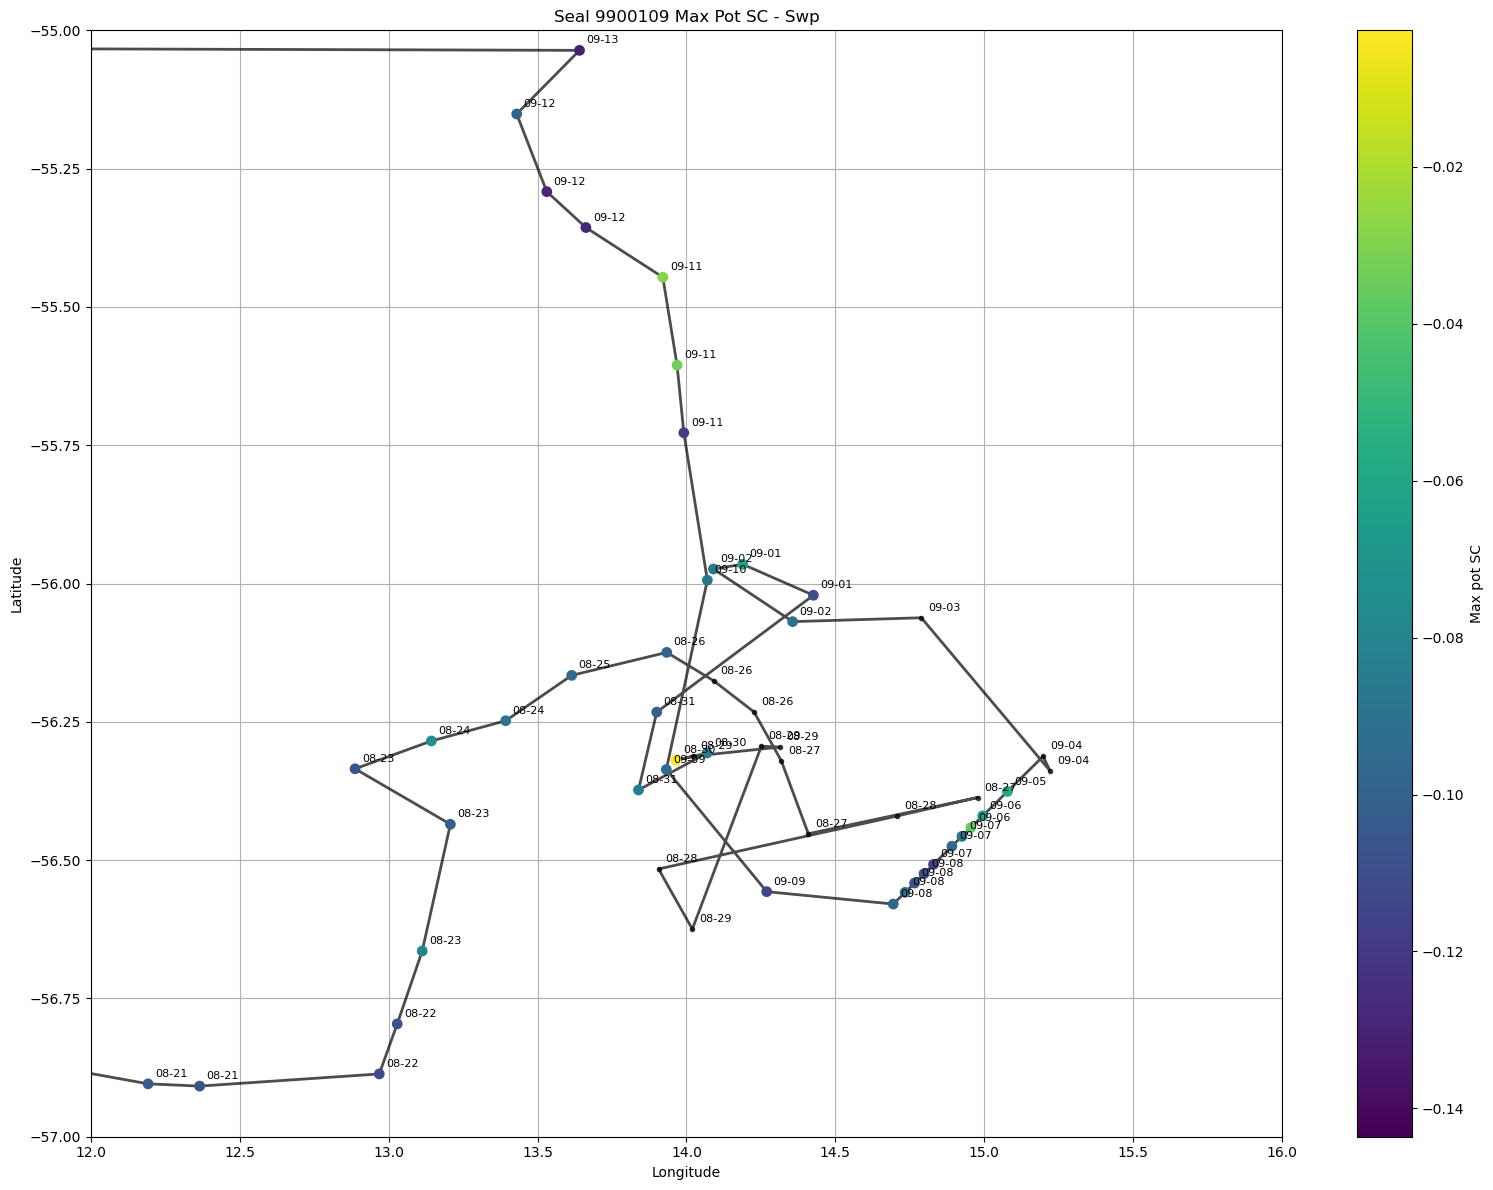

In [12]:
# MOVEMENT OF SEAL WITH MAX POT SC

# Plot
plt.figure(figsize=(16, 12))

# Draw the path line
plt.plot(data1_9900109_all_df['lon'], data1_9900109_all_df['lat'], '.-', linewidth=2, alpha=0.7, label='Movement Path', color = "black")


# Add scatter points with SC coloring
scatter = plt.scatter(data1_9900109_all_df['lon'], data1_9900109_all_df['lat'], c=data1_9900109_all_df["max_ps"], cmap='viridis', 
                      s=60, edgecolors='none', zorder=3, label='Locations')


# Apply the formatter to the colorbar
cbar = plt.colorbar(scatter)
cbar.set_label('Max pot SC')

# Annotate points with time
for i, row in data1_9900109_all_df.iterrows():
    plt.annotate(row['datetimes'].strftime('%m-%d'), (row['lon'], row['lat']), 
                 textcoords="offset points", xytext=(5,5), ha='left', fontsize=8, zorder=4)

# Label axes
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Seal 9900109 Max Pot SC - Swp')

plt.xlim(12,16)
plt.ylim(-57,-55)

plt.grid(True)
plt.tight_layout()
plt.show()

## August Cluster 08-13 to 08-14

### Map View 08-13 to 08-14

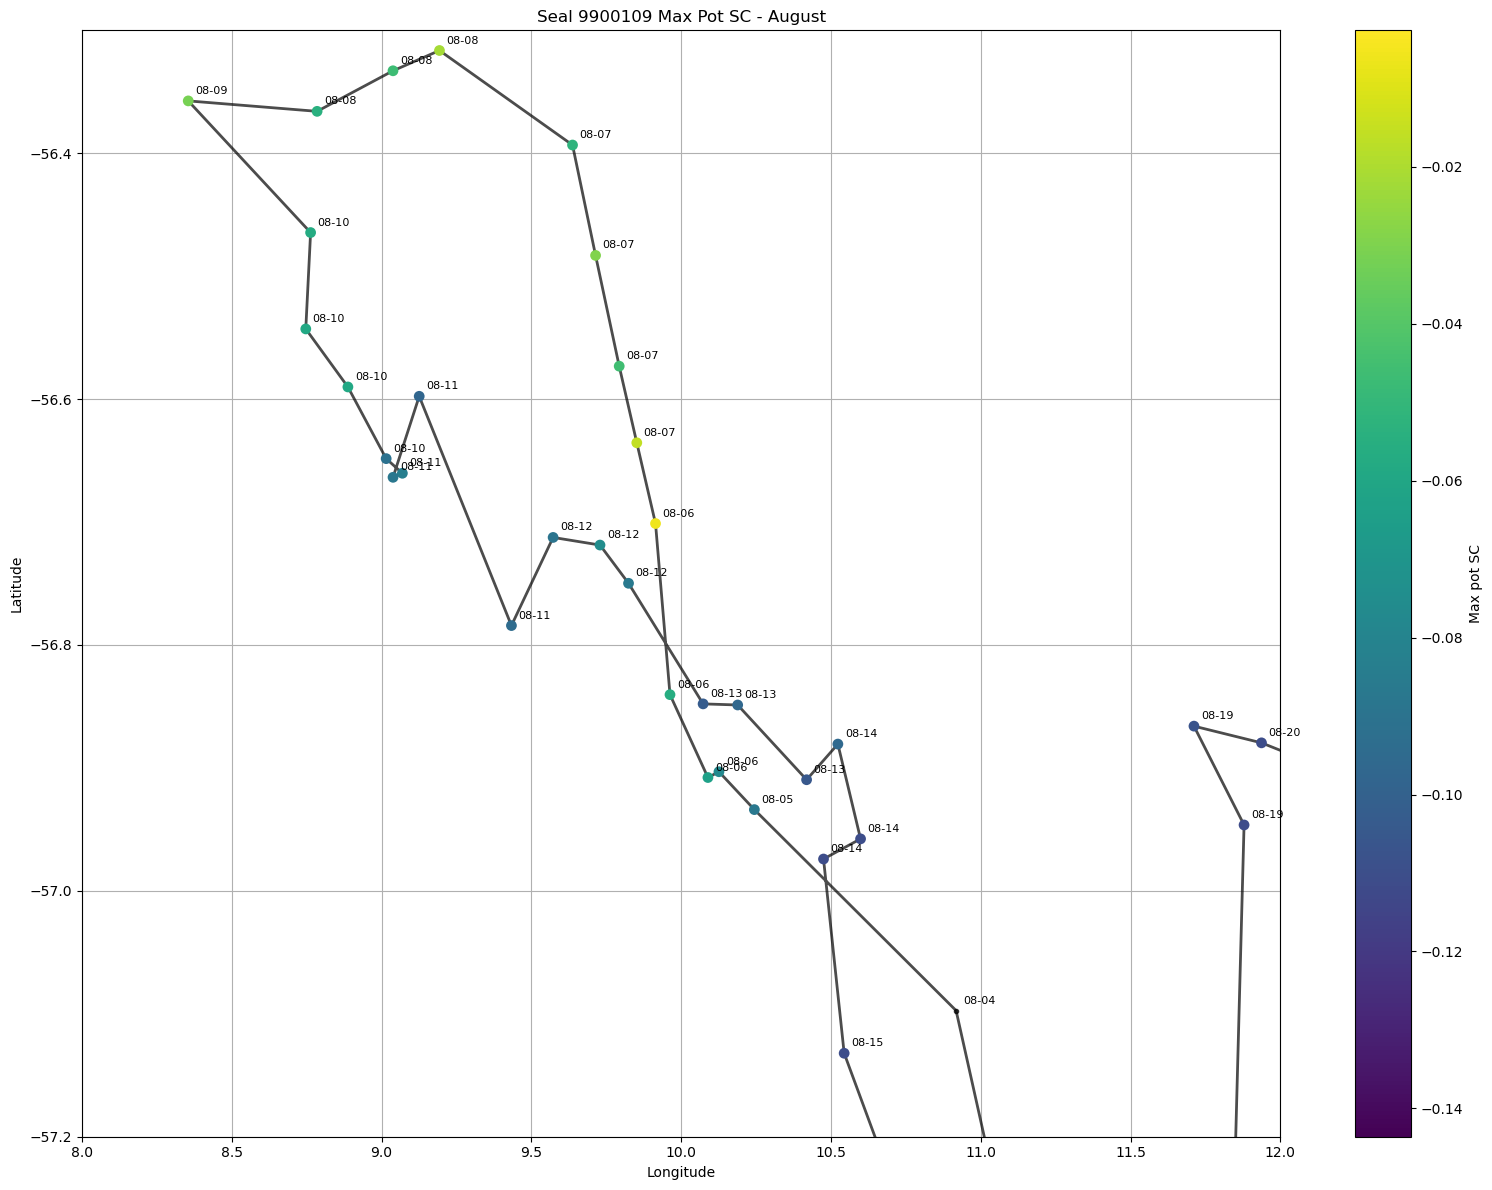

In [13]:
# MOVEMENT OF SEAL WITH MAX POT SC

# Plot
plt.figure(figsize=(16, 12))

# Draw the path line
plt.plot(data1_9900109_all_df['lon'], data1_9900109_all_df['lat'], '.-', linewidth=2, alpha=0.7, label='Movement Path', color = "black")


# Add scatter points with SC coloring
scatter = plt.scatter(data1_9900109_all_df['lon'], data1_9900109_all_df['lat'], c=data1_9900109_all_df["max_ps"], cmap='viridis', 
                      s=60, edgecolors='none', zorder=3, label='Locations')


# Apply the formatter to the colorbar
cbar = plt.colorbar(scatter)
cbar.set_label('Max pot SC')

# Annotate points with time
for i, row in data1_9900109_all_df.iterrows():
    plt.annotate(row['datetimes'].strftime('%m-%d'), (row['lon'], row['lat']), 
                 textcoords="offset points", xytext=(5,5), ha='left', fontsize=8, zorder=4)

# Label axes
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Seal 9900109 Max Pot SC - August')

plt.xlim(8,12)
plt.ylim(-57.2,-56.3)

plt.grid(True)
plt.tight_layout()
plt.show()

In [14]:
start = datetime(2008, 8, 13)
end = datetime(2008, 8, 15)

mask_9900109 = (data1["id"] == 9900109)
mask_time = (data1["datetimes"] < end) & (data1["datetimes"] > start)
mask_final = mask_9900109 & mask_time

cluster_data2 = {key: data2[key][:,mask_final] for key in data2.keys()}
cluster_data2_datetimes = data1["datetimes"][mask_final]

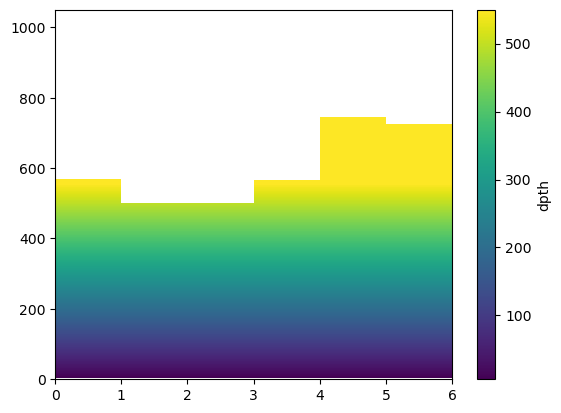

In [15]:
fig, ax = plt.subplots()

pcm = ax.pcolormesh(cluster_data2["dpth"], vmax = 550)

# ax.pcolormesh(cluster_data2_datetimes, cluster_data2["dpth"], cluster_data2["def_pt0"])

# make colorbar
fig.colorbar(pcm, label = "dpth")

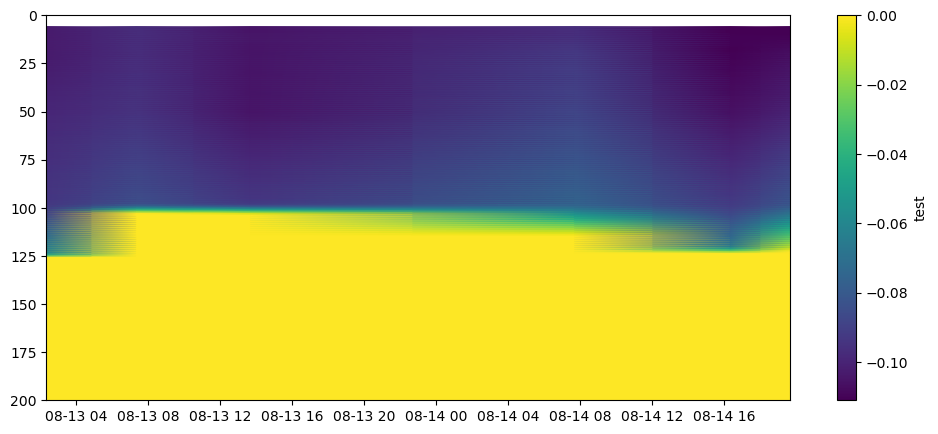

In [16]:
fig, ax = plt.subplots(figsize = (12,5))

depth = np.nan_to_num(cluster_data2["dpth"], nan = 0)

pcm = ax.pcolormesh(cluster_data2_datetimes, depth, cluster_data2["def_pt0"], shading = "gouraud", vmax = 0)

ax.set_ylim(200,0)

# make colorbar
fig.colorbar(pcm, label = "test")

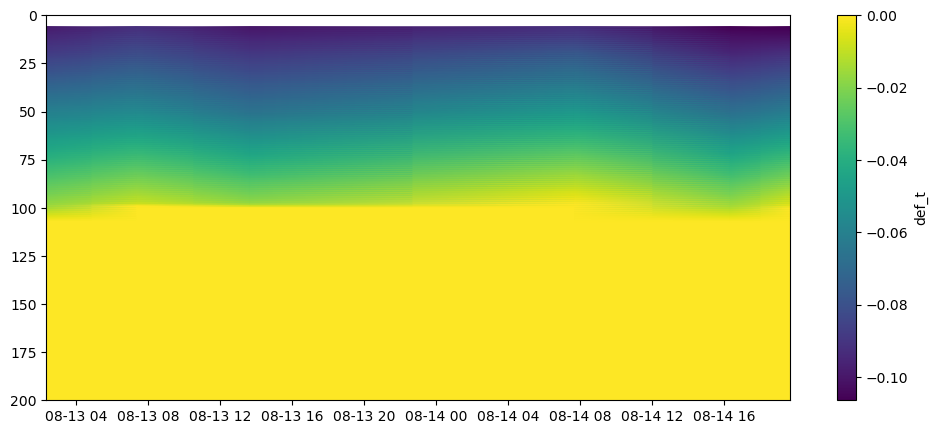

In [17]:
fig, ax = plt.subplots(figsize = (12,5))

depth = np.nan_to_num(cluster_data2["dpth"], nan = 0)

pcm = ax.pcolormesh(cluster_data2_datetimes, depth, cluster_data2["def_t"], shading = "gouraud", vmax = 0)

ax.set_ylim(200,0)

# make colorbar
fig.colorbar(pcm, label = "def_t")

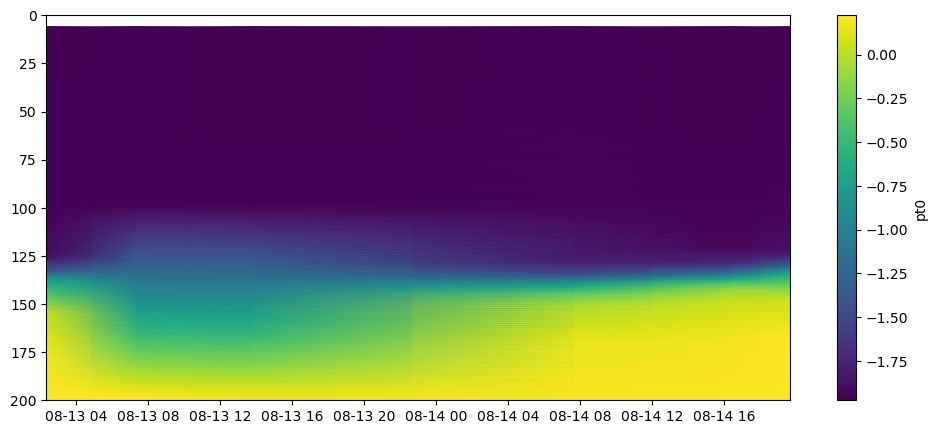

In [18]:
fig, ax = plt.subplots(figsize = (12,5))

depth = np.nan_to_num(cluster_data2["dpth"], nan = 0)

pcm = ax.pcolormesh(cluster_data2_datetimes, depth, cluster_data2["pt0"], shading = "gouraud")

ax.set_ylim(200,0)

# make colorbar
fig.colorbar(pcm, label = "pt0")

## ERA5 Conditions

In [7]:
c_max = 0.99
filename = "ERA5_seaice_netHeat_leadHeat_cmax"+str(c_max)+".nc"
df_seaice = xr.open_dataset(filename)

# only 2008 data
df_seaice_2008 = df_seaice.sel(time=slice("2008-01-01", "2008-12-31"))

# aggregate to daily means
df_seaice_2008_daily = df_seaice_2008.resample(time='D').mean(skipna=True)

sh: getfattr: command not found


In [8]:
# technically this should first be aggregated to daily values cause hourly is clearly overkill
fig = surface_animation(df_seaice_2008_daily, "siconc", "ERA5", "time", "longitude", "latitude", "ice")
fig.write_html("animation.html")